# 🧠 Understanding Self-Attention & Multi-Head Attention
### *From Intuition to Implementation — A Beginner-Friendly Guide*

---

> **Who is this for?**  
> Anyone curious about how modern AI models like GPT, BERT, or ChatGPT work at their core.  
> No prior deep-learning expertise required — just basic Python and high-school math.

---

## 📚 What You'll Learn

| Topic | What It Teaches |
|---|---|
| 🔤 Word Embeddings | How words become numbers |
| 👁️ Simple Self-Attention | How a word "looks at" other words |
| ⚖️ Trainable Self-Attention (Q, K, V) | The real attention mechanism used in GPT |
| 🎭 Causal (Masked) Attention | Why the model can't "cheat" by looking ahead |
| 🎯 Multi-Head Attention | Running multiple attentions in parallel |

---

## 🗺️ The Big Picture

Imagine reading the sentence: **"The animal didn't cross the street because *it* was too tired."**

What does **"it"** refer to — the animal or the street?  
You instantly know it's the **animal** because you mentally linked "it" → "animal".

**Self-Attention** is the mechanism that teaches an AI to do exactly this — to understand *which words are related to which other words*, no matter how far apart they are in a sentence.

Let's build this step by step! 🚀

---
## 📦 Section 1: Setup & Imports

We'll use **PyTorch** — one of the most popular deep learning libraries — along with standard Python tools for math and visualization.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Nice plot styling
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("✅ All imports successful!")
print(f"   PyTorch version: {torch.__version__}")

✅ All imports successful!
   PyTorch version: 2.11.0+cpu


---
## 🔤 Section 2: Words as Vectors (Embeddings)

Before we can apply attention, we need to represent words as **numbers**.  
We do this using **embeddings** — each word becomes a list of numbers called a **vector**.

### Why vectors?
- Math operates on numbers, not words
- Similar words (cat, dog) tend to have similar vectors
- Each number in the vector captures some aspect of the word's meaning

### Our example sentence
We'll work with: **"Your journey starts with one step"**  
Each word is already embedded as a **3-dimensional vector** (in real models, hundreds of dimensions are used).

In [2]:
# Each row = one word, each column = one dimension of meaning
# Think of it as coordinates in "meaning space"

inputs = torch.tensor([
    [0.43, 0.15, 0.89],  # "Your"    → word 1
    [0.55, 0.87, 0.66],  # "journey" → word 2
    [0.57, 0.85, 0.64],  # "starts"  → word 3
    [0.22, 0.58, 0.33],  # "with"    → word 4
    [0.77, 0.25, 0.10],  # "one"     → word 5
    [0.05, 0.80, 0.55],  # "step"    → word 6
])

words = ["Your", "journey", "starts", "with", "one", "step"]

print("Word Embeddings (6 words × 3 dimensions):")
print("-" * 45)
for word, vec in zip(words, inputs):
    print(f"  '{word:8s}' → [{vec[0]:.2f}, {vec[1]:.2f}, {vec[2]:.2f}]")

print(f"\nShape: {inputs.shape}  (6 words, 3 dimensions each)")

Word Embeddings (6 words × 3 dimensions):
---------------------------------------------
  'Your    ' → [0.43, 0.15, 0.89]
  'journey ' → [0.55, 0.87, 0.66]
  'starts  ' → [0.57, 0.85, 0.64]
  'with    ' → [0.22, 0.58, 0.33]
  'one     ' → [0.77, 0.25, 0.10]
  'step    ' → [0.05, 0.80, 0.55]

Shape: torch.Size([6, 3])  (6 words, 3 dimensions each)


### 📊 Visualizing Word Embeddings in 3D

Each word lives at a specific point in 3D space. Words with similar meanings tend to cluster together.  
*(In real models, this is 768 or 1024 dimensions!)*

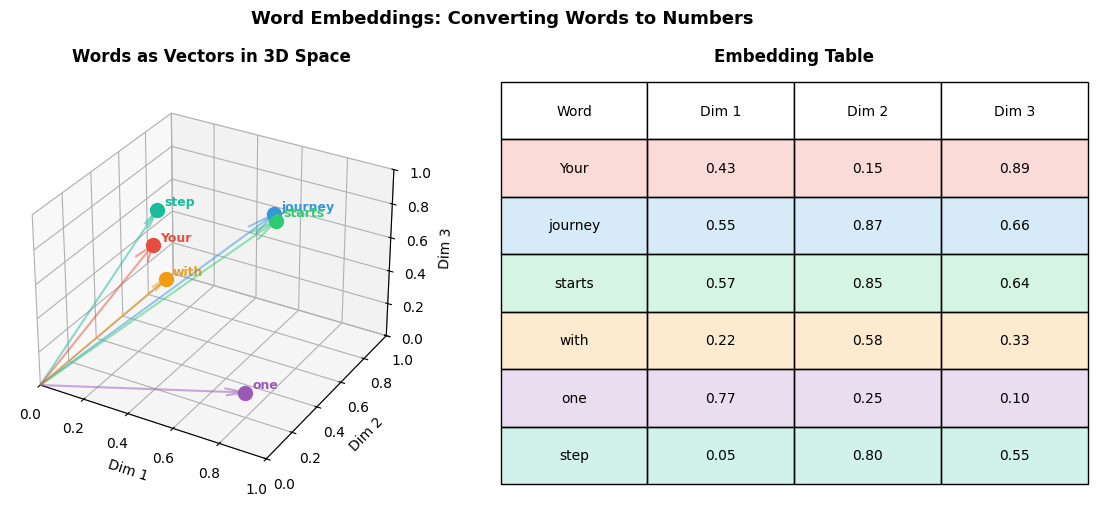

In [3]:
fig = plt.figure(figsize=(12, 5))

# 3D scatter plot
ax = fig.add_subplot(121, projection='3d')
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for i, (word, vec) in enumerate(zip(words, inputs.numpy())):
    ax.scatter(*vec, color=colors[i], s=100, zorder=5)
    ax.text(vec[0]+0.02, vec[1]+0.02, vec[2]+0.02, word, fontsize=9, color=colors[i], fontweight='bold')
    ax.quiver(0, 0, 0, vec[0], vec[1], vec[2], color=colors[i], alpha=0.5, arrow_length_ratio=0.1)

ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2'); ax.set_zlabel('Dim 3')
ax.set_title('Words as Vectors in 3D Space', fontweight='bold', pad=15)
ax.set_xlim([0,1]); ax.set_ylim([0,1]); ax.set_zlim([0,1])

# Table of embeddings
ax2 = fig.add_subplot(122)
ax2.axis('off')
table_data = [[word] + [f"{v:.2f}" for v in vec.tolist()] for word, vec in zip(words, inputs.numpy())]
table = ax2.table(cellText=table_data, colLabels=['Word', 'Dim 1', 'Dim 2', 'Dim 3'],
                  cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False); table.set_fontsize(10)
for j, color in enumerate(colors):
    for k in range(4):
        table[j+1, k].set_facecolor(color + '33')
ax2.set_title('Embedding Table', fontweight='bold', pad=15)

plt.suptitle('Word Embeddings: Converting Words to Numbers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 👁️ Section 3: Simple Self-Attention — "How Much Should I Pay Attention?"

### The Core Idea

Self-attention answers the question:  
> *"When processing word X, how much should I focus on every other word in the sentence?"*

For the word **"journey"**, maybe it should pay a lot of attention to **"starts"** (they're related), and less attention to **"one"** (not very related).

### How It Works — 3 Steps

```
Step 1: Compute Attention SCORES  → How similar is word A to word B?
Step 2: Normalize into WEIGHTS    → Scale scores to sum to 1 (like percentages)
Step 3: Compute CONTEXT VECTOR    → Weighted combination of all words
```

Think of it like a **weighted average**: the context vector for "journey" is a blend of ALL words, but weighted by how relevant each word is to "journey".

In [4]:
# ═══════════════════════════════════════════════
# STEP 1: Compute Attention Scores via DOT PRODUCT
# ═══════════════════════════════════════════════
# We pick "journey" (index 1) as our QUERY word
# A dot product between two vectors measures their similarity
# Higher dot product → more similar → more attention

query = inputs[1]  # "journey"
print("🔍 Query word: 'journey'")
print(f"   Vector: {query.tolist()}")
print()

print("Step 1 — Attention Scores (dot products with each word):")
print("-" * 55)
attn_scores = torch.zeros(inputs.shape[0])
for i, x_i in enumerate(inputs):
    score = torch.dot(x_i, query)
    attn_scores[i] = score
    bar = "█" * int(score.item() * 20)
    print(f"  'journey' · '{words[i]:8s}' = {score.item():.4f}  {bar}")

🔍 Query word: 'journey'
   Vector: [0.550000011920929, 0.8700000047683716, 0.6600000262260437]

Step 1 — Attention Scores (dot products with each word):
-------------------------------------------------------
  'journey' · 'Your    ' = 0.9544  ███████████████████
  'journey' · 'journey ' = 1.4950  █████████████████████████████
  'journey' · 'starts  ' = 1.4754  █████████████████████████████
  'journey' · 'with    ' = 0.8434  ████████████████
  'journey' · 'one     ' = 0.7070  ██████████████
  'journey' · 'step    ' = 1.0865  █████████████████████


In [5]:
# ═══════════════════════════════════════════════
# STEP 2: Normalize Scores into Attention WEIGHTS
# ═══════════════════════════════════════════════
# Use SOFTMAX so all weights are positive and sum to 1
# (like converting scores into percentages/probabilities)

attn_weights = torch.softmax(attn_scores, dim=0)

print("Step 2 — Attention Weights after Softmax (sum to 1.0):")
print("-" * 55)
for i, (w, word) in enumerate(zip(attn_weights, words)):
    bar = "█" * int(w.item() * 40)
    print(f"  Weight on '{word:8s}': {w.item():.4f}  {bar}")
print(f"\n  ✅ Sum of weights: {attn_weights.sum().item():.4f}")

Step 2 — Attention Weights after Softmax (sum to 1.0):
-------------------------------------------------------
  Weight on 'Your    ': 0.1385  █████
  Weight on 'journey ': 0.2379  █████████
  Weight on 'starts  ': 0.2333  █████████
  Weight on 'with    ': 0.1240  ████
  Weight on 'one     ': 0.1082  ████
  Weight on 'step    ': 0.1581  ██████

  ✅ Sum of weights: 1.0000


In [6]:
# ═══════════════════════════════════════════════
# STEP 3: Compute Context Vector (Weighted Sum)
# ═══════════════════════════════════════════════
# The context vector for "journey" = weighted average of ALL word vectors
# Words with higher attention weights contribute MORE to the result

context_vec = torch.zeros(query.shape)
for i, x_i in enumerate(inputs):
    context_vec += attn_weights[i] * x_i

print("Step 3 — Computing Context Vector for 'journey':")
print("-" * 55)
print("  (weighted_sum of all input vectors)")
print()
for i, (w, word, vec) in enumerate(zip(attn_weights, words, inputs)):
    print(f"  {w.item():.4f} × {word:8s} {vec.tolist()}")
print(f"  {'─'*45}")
print(f"  Context Vector: {context_vec.tolist()}")
print()
print("💡 The context vector for 'journey' is a blend of ALL words,")
print("   weighted by how much 'journey' should attend to each one!") 

Step 3 — Computing Context Vector for 'journey':
-------------------------------------------------------
  (weighted_sum of all input vectors)

  0.1385 × Your     [0.4300000071525574, 0.15000000596046448, 0.8899999856948853]
  0.2379 × journey  [0.550000011920929, 0.8700000047683716, 0.6600000262260437]
  0.2333 × starts   [0.5699999928474426, 0.8500000238418579, 0.6399999856948853]
  0.1240 × with     [0.2199999988079071, 0.5799999833106995, 0.33000001311302185]
  0.1082 × one      [0.7699999809265137, 0.25, 0.10000000149011612]
  0.1581 × step     [0.05000000074505806, 0.800000011920929, 0.550000011920929]
  ─────────────────────────────────────────────
  Context Vector: [0.4418657124042511, 0.6514819860458374, 0.5683088302612305]

💡 The context vector for 'journey' is a blend of ALL words,
   weighted by how much 'journey' should attend to each one!


### 📊 Visualizing Attention Weights

The heatmap below shows how much attention each word pair has for each other.

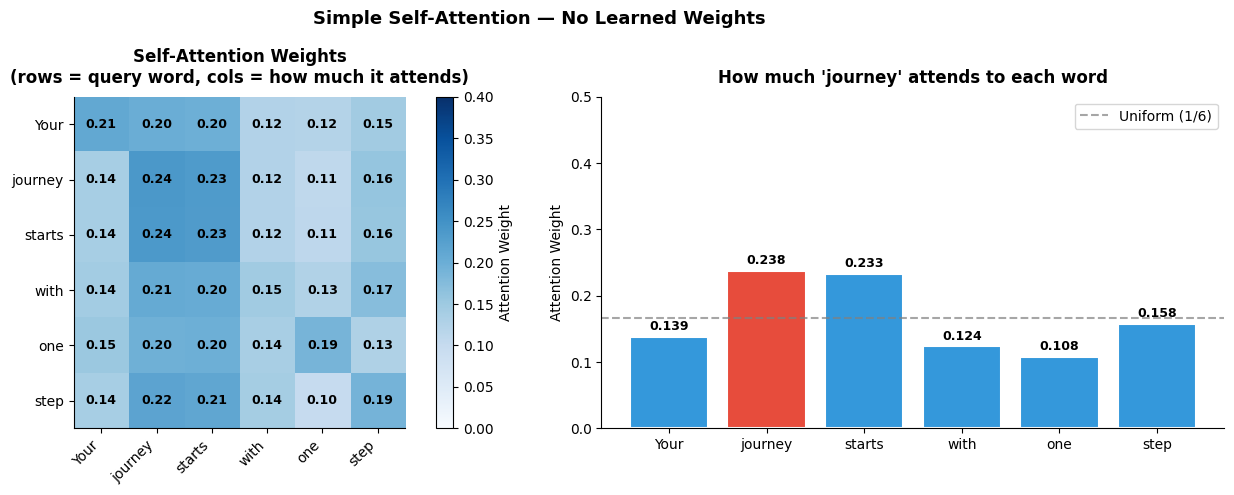

💡 Notice how 'journey', 'starts', and 'step' have higher mutual attention
   — they're action-related words with similar vector directions!


In [7]:
# Compute FULL attention matrix (all words attending to all words)
attn_scores_full = inputs @ inputs.T          # Matrix multiply = all dot products at once
attn_weights_full = torch.softmax(attn_scores_full, dim=-1)  # Normalize each row

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
im = axes[0].imshow(attn_weights_full.detach().numpy(), cmap='Blues', vmin=0, vmax=0.4)
axes[0].set_xticks(range(6)); axes[0].set_xticklabels(words, rotation=45, ha='right')
axes[0].set_yticks(range(6)); axes[0].set_yticklabels(words)
axes[0].set_title('Self-Attention Weights\n(rows = query word, cols = how much it attends)', 
                   fontweight='bold', pad=10)
plt.colorbar(im, ax=axes[0], label='Attention Weight')

# Add text values
for i in range(6):
    for j in range(6):
        val = attn_weights_full[i, j].item()
        axes[0].text(j, i, f'{val:.2f}', ha='center', va='center', 
                    color='white' if val > 0.25 else 'black', fontsize=9, fontweight='bold')

# Bar chart for "journey" attention weights
axes[1].bar(words, attn_weights_full[1].detach().numpy(), 
           color=['#e74c3c' if w == 'journey' else '#3498db' for w in words],
           edgecolor='white', linewidth=1.5)
axes[1].set_title("How much 'journey' attends to each word", fontweight='bold', pad=10)
axes[1].set_ylabel('Attention Weight')
axes[1].set_ylim(0, 0.5)
for i, v in enumerate(attn_weights_full[1].detach().numpy()):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)
axes[1].axhline(y=1/6, color='gray', linestyle='--', alpha=0.7, label='Uniform (1/6)')
axes[1].legend()

plt.suptitle('Simple Self-Attention — No Learned Weights', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 Notice how 'journey', 'starts', and 'step' have higher mutual attention")
print("   — they're action-related words with similar vector directions!")

---
## ⚖️ Section 4: Trainable Self-Attention — Introducing Q, K, and V

### The Problem with Simple Attention

In simple attention, we just used the raw word vectors to compute similarity.  
But what if the raw vectors aren't the best representation for measuring relevance?

**Solution**: Learn three separate *projections* of each word:

| Matrix | Full Name | Role | Analogy |
|--------|-----------|------|---------|
| **W_Q** | Query Weight | "What am I looking for?" | 🔍 A search query |
| **W_K** | Key Weight | "What do I contain?" | 🏷️ A document title/index |
| **W_V** | Value Weight | "What information do I hold?" | 📄 The document content |

### The Library Analogy 📚

Imagine you're searching a library:
- Your **Query (Q)** = the question you typed into the search bar
- Each book's **Key (K)** = the book's title & index keywords  
- Each book's **Value (V)** = the actual content of the book

You find relevant books by matching your query to book keys (attention weights),  
then read their actual content (values) weighted by relevance.

### The Math

```
Q = Input × W_Q    (What is each word looking for?)
K = Input × W_K    (What does each word offer as a key?)
V = Input × W_V    (What is each word's actual content?)

Attention(Q,K,V) = softmax(Q × Kᵀ / √d_k) × V
```

The **√d_k** scaling prevents attention scores from growing too large.

In [8]:
# ─── Setup ────────────────────────────────────────────────────────────────────
d_in  = 3   # Input embedding dimension (our 3D vectors)
d_out = 2   # Output dimension (we project to 2D for illustration)

torch.manual_seed(42)

# Three LEARNABLE weight matrices (these get updated during training)
W_query = nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_key   = nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

print("Three Learnable Weight Matrices:")
print("=" * 50)
print(f"\nW_Query (d_in={d_in} → d_out={d_out}):")
print(W_query)
print(f"\nW_Key   (d_in={d_in} → d_out={d_out}):")
print(W_key)
print(f"\nW_Value (d_in={d_in} → d_out={d_out}):")
print(W_value)

print("\n💡 During training, these matrices LEARN what transformations")
print("   produce the best attention patterns for the task!")

Three Learnable Weight Matrices:

W_Query (d_in=3 → d_out=2):
Parameter containing:
tensor([[0.8823, 0.9150],
        [0.3829, 0.9593],
        [0.3904, 0.6009]])

W_Key   (d_in=3 → d_out=2):
Parameter containing:
tensor([[0.2566, 0.7936],
        [0.9408, 0.1332],
        [0.9346, 0.5936]])

W_Value (d_in=3 → d_out=2):
Parameter containing:
tensor([[0.8694, 0.5677],
        [0.7411, 0.4294],
        [0.8854, 0.5739]])

💡 During training, these matrices LEARN what transformations
   produce the best attention patterns for the task!


In [9]:
# ─── Compute Q, K, V for all words at once (via matrix multiplication) ──────
queries = inputs @ W_query   # Shape: (6, 2)
keys    = inputs @ W_key     # Shape: (6, 2)
values  = inputs @ W_value   # Shape: (6, 2)

print("Original Input Shape:", inputs.shape, "  (6 words × 3 dims)")
print()
print("After projection:")
print(f"  Queries shape: {queries.shape}  (6 words × 2 dims)")
print(f"  Keys    shape: {keys.shape}  (6 words × 2 dims)")
print(f"  Values  shape: {values.shape}  (6 words × 2 dims)")

print()
print("Queries (Q) — What each word is looking for:")
for word, q in zip(words, queries):
    print(f"  '{word:8s}' → [{q[0]:.3f}, {q[1]:.3f}]")

Original Input Shape: torch.Size([6, 3])   (6 words × 3 dims)

After projection:
  Queries shape: torch.Size([6, 2])  (6 words × 2 dims)
  Keys    shape: torch.Size([6, 2])  (6 words × 2 dims)
  Values  shape: torch.Size([6, 2])  (6 words × 2 dims)

Queries (Q) — What each word is looking for:
  'Your    ' → [0.784, 1.072]
  'journey ' → [1.076, 1.734]
  'starts  ' → [1.078, 1.722]
  'with    ' → [0.545, 0.956]
  'one     ' → [0.814, 1.004]
  'step    ' → [0.565, 1.144]


In [10]:
# ─── Compute Scaled Dot-Product Attention ─────────────────────────────────────
# Step 1: Attention scores = Q × Kᵀ
attn_scores = queries @ keys.T   # (6, 2) × (2, 6) = (6, 6)

# Step 2: Scale by √d_k  (prevents vanishing/exploding gradients)
d_k = keys.shape[-1]
attn_scores_scaled = attn_scores / (d_k ** 0.5)

# Step 3: Softmax → weights
attn_weights = torch.softmax(attn_scores_scaled, dim=-1)

# Step 4: Context vectors = attention_weights × V
context_vecs = attn_weights @ values

print("Attention Weights (after Q·Kᵀ/√d_k + softmax):")
print(attn_weights.detach().numpy().round(3))
print()
print("Context Vectors (final output):")
for word, vec in zip(words, context_vecs):
    print(f"  '{word:8s}' → [{vec[0]:.4f}, {vec[1]:.4f}]")
print()
print("💡 Each context vector is a rich blend of information from ALL words,")
print("   informed by learned Q, K, V projections!")

Attention Weights (after Q·Kᵀ/√d_k + softmax):
[[0.172 0.236 0.232 0.112 0.11  0.14 ]
 [0.172 0.268 0.262 0.088 0.09  0.12 ]
 [0.172 0.268 0.262 0.088 0.09  0.12 ]
 [0.175 0.22  0.217 0.121 0.125 0.142]
 [0.17  0.235 0.231 0.113 0.108 0.142]
 [0.177 0.226 0.223 0.116 0.122 0.137]]

Context Vectors (final output):
  'Your    ' → [1.3751, 0.8610]
  'journey ' → [1.4201, 0.8892]
  'starts  ' → [1.4198, 0.8890]
  'with    ' → [1.3533, 0.8476]
  'one     ' → [1.3746, 0.8606]
  'step    ' → [1.3620, 0.8532]

💡 Each context vector is a rich blend of information from ALL words,
   informed by learned Q, K, V projections!


### 📊 Why Scale by √d_k? — A Demonstration

Without scaling, dot products can become very large as the dimension grows, which causes softmax to output nearly one-hot distributions (almost all attention on one word). This kills the gradient and makes training unstable.

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ─── Left: Effect of scaling on softmax output ───────────────────────────────
scores_raw    = torch.tensor([2.1, 0.8, 1.5, -0.5, 1.2])
scores_scaled = scores_raw * 8  # Simulate large, unscaled scores

sw_raw    = torch.softmax(scores_raw, dim=0).numpy()
sw_scaled = torch.softmax(scores_scaled, dim=0).numpy()

x_pos = np.arange(5)
axes[0].bar(x_pos - 0.2, sw_raw,    0.35, label='Normal scores',  color='#3498db', alpha=0.85)
axes[0].bar(x_pos + 0.2, sw_scaled, 0.35, label='×8 (too large)', color='#e74c3c', alpha=0.85)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([f'w{i+1}' for i in range(5)])
axes[0].set_title('Effect of Large Scores on Softmax')
(Too sharp = bad gradients!)', fontweight='bold')
axes[0].set_ylabel('Attention Weight'); axes[0].legend()
axes[0].axhline(0.2, color='gray', linestyle='--', alpha=0.5, label='Uniform (0.2)')

# ─── Middle: Variance grows with dimension WITHOUT scaling ─────────────────
dims = [4, 8, 16, 32, 64, 128, 256]
var_before, var_after = [], []
for dim in dims:
    dot_prods = [np.dot(np.random.randn(dim), np.random.randn(dim)) for _ in range(2000)]
    scaled    = [d / np.sqrt(dim) for d in dot_prods]
    var_before.append(np.var(dot_prods))
    var_after.append(np.var(scaled))

axes[1].plot(dims, var_before, 'o-', color='#e74c3c', label='Without scaling', lw=2, markersize=6)
axes[1].plot(dims, var_after,  's-', color='#2ecc71', label='With √d scaling', lw=2, markersize=6)
axes[1].axhline(1, color='gray', linestyle='--', alpha=0.6, label='Variance = 1 (ideal)')
axes[1].set_xlabel('Embedding Dimension (d_k)'); axes[1].set_ylabel('Variance of Dot Products')
axes[1].set_title('Variance of Q·Kᵀ vs. Dimension
(Scaling keeps variance ≈ 1)', fontweight='bold')
axes[1].legend(); axes[1].set_yscale('log')

# ─── Right: QKV pipeline diagram ─────────────────────────────────────────────
ax = axes[2]; ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
ax.set_title('Q, K, V Attention Pipeline', fontweight='bold')

def box(ax, x, y, w, h, txt, color, fontsize=9):
    ax.add_patch(plt.Rectangle((x, y), w, h, color=color, ec='white', lw=2, zorder=3))
    ax.text(x+w/2, y+h/2, txt, ha='center', va='center', fontsize=fontsize,
            fontweight='bold', color='white', zorder=4)

def arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))

box(ax, 3.5, 8.2, 3, 1.0, 'Input Words
(embeddings)', '#7f8c8d')
box(ax, 0.5, 5.5, 2.5, 1.2, 'W_Q
(Query)', '#e74c3c')
box(ax, 3.75, 5.5, 2.5, 1.2, 'W_K
(Key)', '#3498db')
box(ax, 7.0, 5.5, 2.5, 1.2, 'W_V
(Value)', '#2ecc71')
box(ax, 1.5, 3.2, 7.0, 1.2, 'Q·Kᵀ / √d_k  →  softmax  →  Attention Weights', '#9b59b6', 8)
box(ax, 2.5, 1.0, 5.0, 1.2, 'Attention Weights × V  =  Context Vectors', '#e67e22', 8)

for cx in [1.75, 5.0, 8.25]:
    arrow(ax, 5.0, 8.2, cx, 6.7)
arrow(ax, 1.75, 5.5, 4.0, 4.4)
arrow(ax, 5.0, 5.5, 5.0, 4.4)
arrow(ax, 8.25, 5.5, 6.5, 4.4)
arrow(ax, 5.0, 3.2, 5.0, 2.2)

plt.suptitle('Trainable Self-Attention: Q, K, V Mechanism', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

SyntaxError: unterminated string literal (detected at line 16) (2201822131.py, line 16)

### 🧹 Clean Implementation: `SelfAttention` Class

Let's wrap everything into a clean, reusable PyTorch module.

In [ ]:
class SelfAttention(nn.Module):
    """
    Trainable Self-Attention Module
    
    Parameters:
        d_in  : input embedding dimension
        d_out : output embedding dimension
    """
    def __init__(self, d_in, d_out):
        super().__init__()
        # Three learnable projection matrices
        self.W_query = nn.Linear(d_in, d_out, bias=False)
        self.W_key   = nn.Linear(d_in, d_out, bias=False)
        self.W_value = nn.Linear(d_in, d_out, bias=False)

    def forward(self, x):
        # Step 1: Project inputs into Query, Key, Value spaces
        Q = self.W_query(x)
        K = self.W_key(x)
        V = self.W_value(x)
        
        # Step 2: Scaled dot-product attention scores
        d_k = K.shape[-1]
        attn_scores = Q @ K.transpose(-2, -1) / (d_k ** 0.5)
        
        # Step 3: Softmax → attention weights
        attn_weights = torch.softmax(attn_scores, dim=-1)
        
        # Step 4: Weighted sum of values
        context_vecs = attn_weights @ V
        return context_vecs, attn_weights

# ─── Test it! ─────────────────────────────────────────────────────────────────
torch.manual_seed(42)
sa = SelfAttention(d_in=3, d_out=2)
context_vecs, attn_weights = sa(inputs)

print("SelfAttention output:")
print(f"  Input  shape: {inputs.shape}")
print(f"  Output shape: {context_vecs.shape}")
print()
print("Context Vectors:")
for word, vec in zip(words, context_vecs):
    print(f"  '{word:8s}' → [{vec[0]:.4f}, {vec[1]:.4f}]")

SelfAttention output:
  Input  shape: torch.Size([6, 3])
  Output shape: torch.Size([6, 2])

Context Vectors:
  'Your    ' → [0.3755, 0.2777]
  'journey ' → [0.3761, 0.2831]
  'starts  ' → [0.3761, 0.2833]
  'with    ' → [0.3768, 0.2763]
  'one     ' → [0.3754, 0.2836]
  'step    ' → [0.3772, 0.2746]


---
## 🎭 Section 5: Causal (Masked) Attention — "Don't Look Ahead!"

### The Problem: Information Leakage

When training a language model to **predict the next word**,  
it would be *cheating* if the model could look at future words while making its prediction.

**Example**: Predicting the 3rd word in "Your journey starts..."  
The model should only see ["Your", "journey"], NOT "starts" or anything after it.

### The Solution: Causal Masking

We **mask** (block) the model from attending to future tokens by setting those attention scores to **-∞** before softmax.

```
Without mask:       With causal mask:
 ┌──────────────┐    ┌──────────────┐
 │ w w w w w w │    │ w            │  ← "Your" only sees itself
 │ w w w w w w │    │ w w          │  ← "journey" sees Your+journey
 │ w w w w w w │    │ w w w        │  ← "starts" sees first 3 words
 │ w w w w w w │    │ w w w w      │  ← ...
 │ w w w w w w │    │ w w w w w    │
 │ w w w w w w │    │ w w w w w w  │  ← "step" sees everything
 └──────────────┘    └──────────────┘
    (bidirectional)      (causal / unidirectional)
```

This makes the model **autoregressive** — it generates one word at a time, each based only on past context.

In [ ]:
# ─── Build the Causal Mask ────────────────────────────────────────────────────
n = 6  # number of tokens

# Create a mask: upper triangle = True (positions to BLOCK)
mask = torch.triu(torch.ones(n, n), diagonal=1).bool()

print("Upper triangular mask (True = BLOCKED positions):")
print(mask.int().numpy())
print()

# Compute attention scores using SelfAttention
torch.manual_seed(42)
sa = SelfAttention(d_in=3, d_out=2)
Q = sa.W_query(inputs)
K = sa.W_key(inputs)
d_k = K.shape[-1]

attn_scores = Q @ K.transpose(-2, -1) / (d_k ** 0.5)

# Apply mask: set blocked positions to -infinity
masked_scores = attn_scores.masked_fill(mask, float('-inf'))

print("Attention scores after masking (future = -inf):")
print(masked_scores.detach().numpy().round(2))

Upper triangular mask (True = BLOCKED positions):
[[0 1 1 1 1 1]
 [0 0 1 1 1 1]
 [0 0 0 1 1 1]
 [0 0 0 0 1 1]
 [0 0 0 0 0 1]
 [0 0 0 0 0 0]]

Attention scores after masking (future = -inf):
[[ 0.04  -inf  -inf  -inf  -inf  -inf]
 [ 0.15  0.24  -inf  -inf  -inf  -inf]
 [ 0.15  0.25  0.23  -inf  -inf  -inf]
 [ 0.09  0.13  0.12  0.08  -inf  -inf]
 [ 0.12  0.23  0.21  0.16 -0.08  -inf]
 [ 0.09  0.11  0.1   0.07 -0.02  0.12]]


In [ ]:
# ─── Softmax Turns -inf → 0 ──────────────────────────────────────────────────
causal_weights = torch.softmax(masked_scores, dim=-1)

print("Causal Attention Weights (e^(-inf) = 0, rows sum to 1):")
print(causal_weights.detach().numpy().round(3))
print()
print("Row sums (each word only over words it can see):")
print(causal_weights.sum(dim=-1).detach().numpy().round(3))

Causal Attention Weights (e^(-inf) = 0, rows sum to 1):
[[1.    0.    0.    0.    0.    0.   ]
 [0.478 0.522 0.    0.    0.    0.   ]
 [0.315 0.345 0.34  0.    0.    0.   ]
 [0.246 0.255 0.254 0.245 0.    0.   ]
 [0.197 0.219 0.217 0.205 0.162 0.   ]
 [0.168 0.172 0.171 0.165 0.151 0.174]]

Row sums (each word only over words it can see):
[1. 1. 1. 1. 1. 1.]


C:\Users\krishna\AppData\Local\Temp\ipykernel_8068\2885886300.py:33: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\krishna\AppData\Local\Temp\ipykernel_8068\2885886300.py:33: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\langchain\myvenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\langchain\myvenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


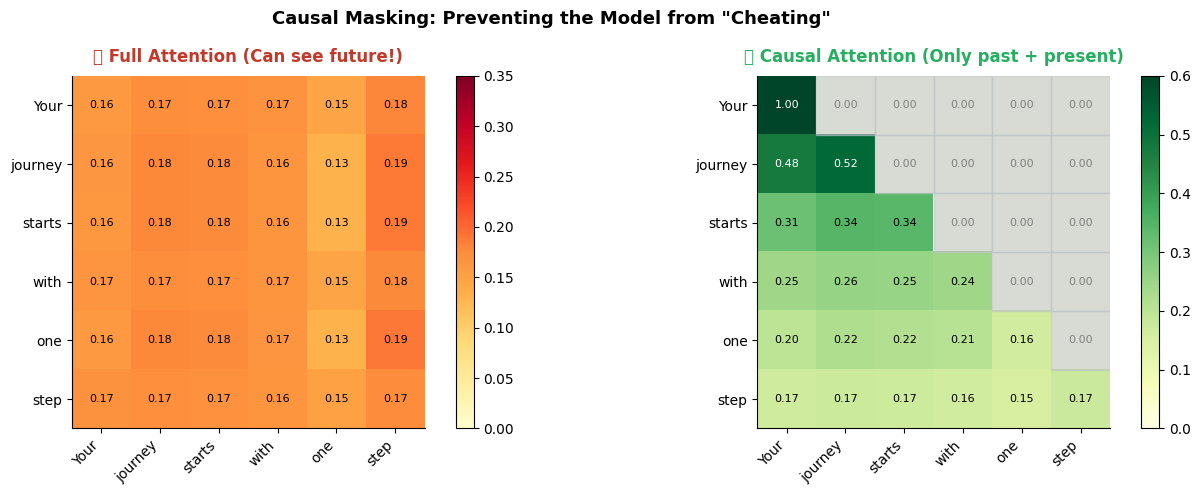

💡 Gray cells = masked (blocked) positions. The model cannot use these during training.


In [ ]:
# ─── Visualization: Side-by-Side Comparison ──────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Full (bidirectional) attention
full_weights = torch.softmax(attn_scores, dim=-1).detach().numpy()
im1 = ax1.imshow(full_weights, cmap='YlOrRd', vmin=0, vmax=0.35)
ax1.set_xticks(range(n)); ax1.set_xticklabels(words, rotation=45, ha='right')
ax1.set_yticks(range(n)); ax1.set_yticklabels(words)
ax1.set_title('❌ Full Attention (Can see future!)', fontweight='bold', color='#c0392b', pad=10)
plt.colorbar(im1, ax=ax1)
for i in range(n):
    for j in range(n):
        ax1.text(j, i, f'{full_weights[i,j]:.2f}', ha='center', va='center',
                color='white' if full_weights[i,j] > 0.2 else 'black', fontsize=8)

# Causal (masked) attention
cw = causal_weights.detach().numpy()
im2 = ax2.imshow(cw, cmap='YlGn', vmin=0, vmax=0.6)
ax2.set_xticks(range(n)); ax2.set_xticklabels(words, rotation=45, ha='right')
ax2.set_yticks(range(n)); ax2.set_yticklabels(words)
ax2.set_title('✅ Causal Attention (Only past + present)', fontweight='bold', color='#27ae60', pad=10)
plt.colorbar(im2, ax=ax2)
for i in range(n):
    for j in range(n):
        ax2.text(j, i, f'{cw[i,j]:.2f}', ha='center', va='center',
                color='white' if cw[i,j] > 0.35 else ('gray' if j > i else 'black'), fontsize=8)
    # Shade future positions
    for j in range(i+1, n):
        ax2.add_patch(mpatches.Rectangle((j-0.5, i-0.5), 1, 1, 
                      color='#bdc3c7', alpha=0.6, zorder=2))

plt.suptitle('Causal Masking: Preventing the Model from "Cheating"', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 Gray cells = masked (blocked) positions. The model cannot use these during training.")

### 🧹 Clean CausalAttention Class with Dropout

**Dropout** is a regularization technique that randomly zeros out some attention weights during training, which prevents the model from over-relying on any single connection.

In [ ]:
class CausalAttention(nn.Module):
    """
    Causal (Masked) Self-Attention with Dropout
    
    Parameters:
        d_in           : input embedding dimension
        d_out          : output embedding dimension
        context_length : maximum sequence length
        dropout        : dropout probability (e.g. 0.1 = drop 10% during training)
    """
    def __init__(self, d_in, d_out, context_length, dropout=0.1):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=False)
        self.W_key   = nn.Linear(d_in, d_out, bias=False)
        self.W_value = nn.Linear(d_in, d_out, bias=False)
        self.dropout = nn.Dropout(dropout)
        
        # register_buffer: not a learnable param, but moves with model to GPU etc.
        self.register_buffer('mask',
            torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        B, T, d_in = x.shape  # Batch, Tokens, Dim
        Q = self.W_query(x)
        K = self.W_key(x)
        V = self.W_value(x)
        
        # Scaled dot product
        attn_scores = Q @ K.transpose(-2, -1) / (K.shape[-1] ** 0.5)
        
        # Apply causal mask
        attn_scores = attn_scores.masked_fill(
            self.mask[:T, :T].bool(), float('-inf'))
        
        # Softmax + dropout
        attn_weights = torch.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        
        return attn_weights @ V

# ─── Test with a BATCH of inputs ──────────────────────────────────────────────
# Real models process multiple sequences at once (a "batch")
batch = torch.stack([inputs, inputs], dim=0)  # Batch of 2 identical sentences

torch.manual_seed(42)
ca = CausalAttention(d_in=3, d_out=2, context_length=6, dropout=0.0)
out = ca(batch)

print(f"Batch shape (input):  {batch.shape}   → (batch=2, tokens=6, dim=3)")
print(f"Output shape:         {out.shape}   → (batch=2, tokens=6, dim=2)")
print()
print("Context vectors for first sentence:")
for word, vec in zip(words, out[0]):
    print(f"  '{word:8s}' → [{vec[0]:.4f}, {vec[1]:.4f}]")

Batch shape (input):  torch.Size([2, 6, 3])   → (batch=2, tokens=6, dim=3)
Output shape:         torch.Size([2, 6, 2])   → (batch=2, tokens=6, dim=2)

Context vectors for first sentence:
  'Your    ' → [0.4429, 0.1077]
  'journey ' → [0.4656, 0.2597]
  'starts  ' → [0.4732, 0.3030]
  'with    ' → [0.4135, 0.2921]
  'one     ' → [0.4078, 0.2567]
  'step    ' → [0.3772, 0.2746]


---
## 🎯 Section 6: Multi-Head Attention — Multiple Perspectives at Once

### The Motivation

A single attention head captures **one type of relationship** between words.  
But language is rich — words relate in many ways:

- **Grammatical**: subject ↔ verb
- **Semantic**: synonym ↔ synonym  
- **Co-reference**: pronoun ↔ noun it refers to
- **Positional**: neighboring words

**Multi-Head Attention** runs **H parallel attention heads**, each free to specialize in different patterns.

### How It Works

```
Input → [Head 1] ─┐
       [Head 2] ─┤
       [Head 3] ─┼─→ Concatenate → Linear Projection → Output
       ...       ─┤
       [Head H] ─┘
```

Each head gets its own set of W_Q, W_K, W_V matrices.  
They all run in parallel, then their outputs are concatenated and projected.

### Efficiency Trick: Weight Splitting

Instead of creating H separate attention modules, we can be clever:  
1. Project all inputs into a **big** Q, K, V matrix (dimension = `d_out`)
2. **Split** that matrix into H heads (each head gets `d_out / H` dimensions)
3. Run all heads **simultaneously** using tensor operations

This is equivalent but **much faster** because it uses a single matrix multiplication!

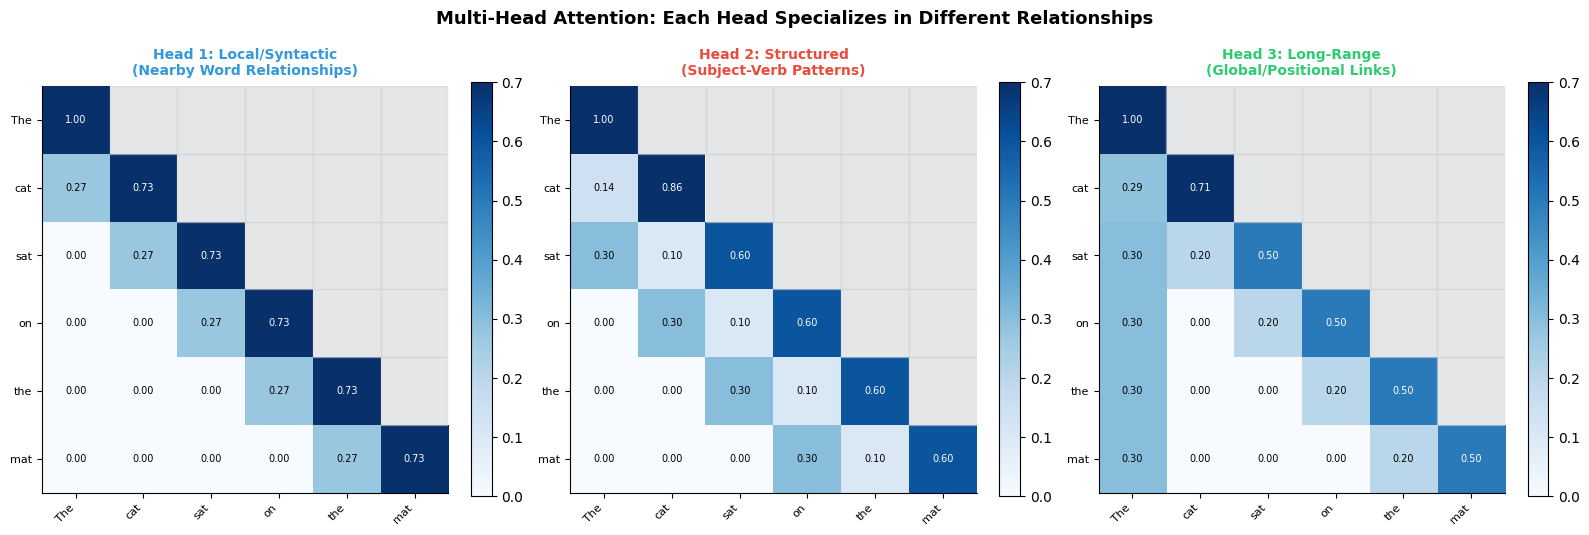

💡 Each attention head learns its own pattern.
   Combining multiple heads gives the model a richer understanding of the sentence.


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Example words
words = ["The", "cat", "sat", "on", "the", "mat"]
n = len(words)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

np.random.seed(42)

def make_pattern(pattern_type, n=6):
    M = np.zeros((n, n))

    if pattern_type == 'local':  # Local (neighboring words)
        for i in range(n):
            for j in range(n):
                if abs(i - j) <= 1 and j <= i:
                    M[i, j] = np.exp(-abs(i - j))

    elif pattern_type == 'subject_verb':  # Structured pattern
        for i in range(n):
            M[i, i] = 0.6
            if i > 1:
                M[i, i - 2] = 0.3
            if i > 0:
                M[i, i - 1] = 0.1

    elif pattern_type == 'long_range':  # Long-range dependencies
        for i in range(n):
            M[i, 0] = 0.3
            M[i, i] = 0.5
            if i > 0:
                M[i, i - 1] = 0.2

    # Apply causal mask
    M = np.tril(M)

    # Normalize rows
    row_sums = M.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    M = M / row_sums

    return M

patterns = [
    (
        make_pattern('local', n),
        'Head 1: Local/Syntactic\n(Nearby Word Relationships)',
        '#3498db'
    ),
    (
        make_pattern('subject_verb', n),
        'Head 2: Structured\n(Subject-Verb Patterns)',
        '#e74c3c'
    ),
    (
        make_pattern('long_range', n),
        'Head 3: Long-Range\n(Global/Positional Links)',
        '#2ecc71'
    ),
]

for ax, (M, title, color) in zip(axes, patterns):

    im = ax.imshow(M, cmap='Blues', vmin=0, vmax=0.7)

    ax.set_xticks(range(n))
    ax.set_xticklabels(words, rotation=45, ha='right', fontsize=8)

    ax.set_yticks(range(n))
    ax.set_yticklabels(words, fontsize=8)

    ax.set_title(title, fontweight='bold', color=color, pad=8, fontsize=10)

    plt.colorbar(im, ax=ax, fraction=0.046)

    for i in range(n):
        for j in range(i + 1):

            value = M[i, j]

            ax.text(
                j, i, f'{value:.2f}',
                ha='center',
                va='center',
                fontsize=7,
                color='white' if value > 0.4 else 'black'
            )

        # Grey-out future tokens (causal mask)
        for j in range(i + 1, n):
            ax.add_patch(
                mpatches.Rectangle(
                    (j - 0.5, i - 0.5),
                    1,
                    1,
                    color='lightgray',
                    alpha=0.5
                )
            )

plt.suptitle(
    'Multi-Head Attention: Each Head Specializes in Different Relationships',
    fontsize=13,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

print("💡 Each attention head learns its own pattern.")
print("   Combining multiple heads gives the model a richer understanding of the sentence.")

In [12]:
class MultiHeadAttention(nn.Module):
    """
    Multi-Head Causal Self-Attention (Efficient Implementation)
    
    Key idea: Instead of running H separate attention modules,
    we project to a large space and SPLIT into H heads.
    This is mathematically equivalent but much faster.
    
    Parameters:
        d_in           : input embedding dimension
        d_out          : total output dimension (d_out / num_heads = per-head dimension)
        context_length : maximum sequence length
        num_heads      : number of parallel attention heads
        dropout        : dropout probability
    """
    def __init__(self, d_in, d_out, context_length, num_heads, dropout=0.1):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"
        
        self.d_out     = d_out
        self.num_heads = num_heads
        self.head_dim  = d_out // num_heads   # Each head's private dimension
        
        # Single large projection (more efficient than separate W_Q, W_K, W_V per head)
        self.W_query = nn.Linear(d_in, d_out, bias=False)
        self.W_key   = nn.Linear(d_in, d_out, bias=False)
        self.W_value = nn.Linear(d_in, d_out, bias=False)
        
        # Final projection to combine head outputs
        self.out_proj = nn.Linear(d_out, d_out, bias=False)
        self.dropout  = nn.Dropout(dropout)
        
        self.register_buffer('mask',
            torch.triu(torch.ones(context_length, context_length), diagonal=1))
    
    def forward(self, x):
        B, T, d_in = x.shape   # Batch, Tokens, Input Dim
        
        # ── Step 1: Project to Q, K, V ──────────────────────────────────────────
        Q = self.W_query(x)  # (B, T, d_out)
        K = self.W_key(x)
        V = self.W_value(x)
        
        # ── Step 2: SPLIT into H heads ──────────────────────────────────────────
        # Reshape: (B, T, d_out) → (B, T, H, head_dim) → (B, H, T, head_dim)
        Q = Q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        # Now shape = (B, num_heads, T, head_dim) — all heads in parallel!
        
        # ── Step 3: Scaled Dot-Product Attention for ALL heads at once ─────────
        attn_scores = Q @ K.transpose(-2, -1) / (self.head_dim ** 0.5)
        
        # Apply causal mask
        attn_scores = attn_scores.masked_fill(
            self.mask[:T, :T].bool(), float('-inf'))
        
        attn_weights = torch.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        
        # ── Step 4: Weighted sum of values, then MERGE heads back ──────────────
        # (B, H, T, head_dim) → (B, T, H, head_dim) → (B, T, d_out)
        out = (attn_weights @ V).transpose(1, 2).contiguous().view(B, T, self.d_out)
        
        # ── Step 5: Final projection to mix head outputs ────────────────────────
        out = self.out_proj(out)
        return out, attn_weights

print("MultiHeadAttention class defined! ✅")

MultiHeadAttention class defined! ✅


In [13]:
# ─── Test Multi-Head Attention ────────────────────────────────────────────────
torch.manual_seed(42)
batch = torch.stack([inputs, inputs], dim=0)  # (batch=2, tokens=6, dim=3)

mha = MultiHeadAttention(d_in=3, d_out=4, context_length=6, num_heads=2, dropout=0.0)
output, attn_weights = mha(batch)

print("Multi-Head Attention Test:")
print(f"  Input  shape: {batch.shape}     → (2 sentences, 6 tokens, 3 dims each)")
print(f"  Output shape: {output.shape}     → (2 sentences, 6 tokens, 4 dims each)")
print(f"  Attn weights: {attn_weights.shape} → (2 batch, 2 heads, 6 tokens, 6 tokens)")
print()
print("Context vectors for Head 1, Sentence 1:")
for word, vec in zip(words, output[0]):
    print(f"  '{word:8s}' → {vec.detach().tolist()}")

Multi-Head Attention Test:
  Input  shape: torch.Size([2, 6, 3])     → (2 sentences, 6 tokens, 3 dims each)
  Output shape: torch.Size([2, 6, 4])     → (2 sentences, 6 tokens, 4 dims each)
  Attn weights: torch.Size([2, 2, 6, 6]) → (2 batch, 2 heads, 6 tokens, 6 tokens)

Context vectors for Head 1, Sentence 1:
  'Your    ' → [-0.3139481842517853, 0.29957661032676697, 0.21922719478607178, -0.23387235403060913]
  'journey ' → [-0.2900071442127228, 0.18905885517597198, 0.10769808292388916, -0.16486608982086182]
  'starts  ' → [-0.28156083822250366, 0.15281452238559723, 0.07183091342449188, -0.1431121975183487]
  'with    ' → [-0.2440650761127472, 0.11465292423963547, 0.043988779187202454, -0.10639642179012299]
  'one     ' → [-0.22658462822437286, 0.10678574442863464, 0.04257969558238983, -0.12188754230737686]
  'step    ' → [-0.2146909534931183, 0.08803246915340424, 0.025294415652751923, -0.0912511870265007]


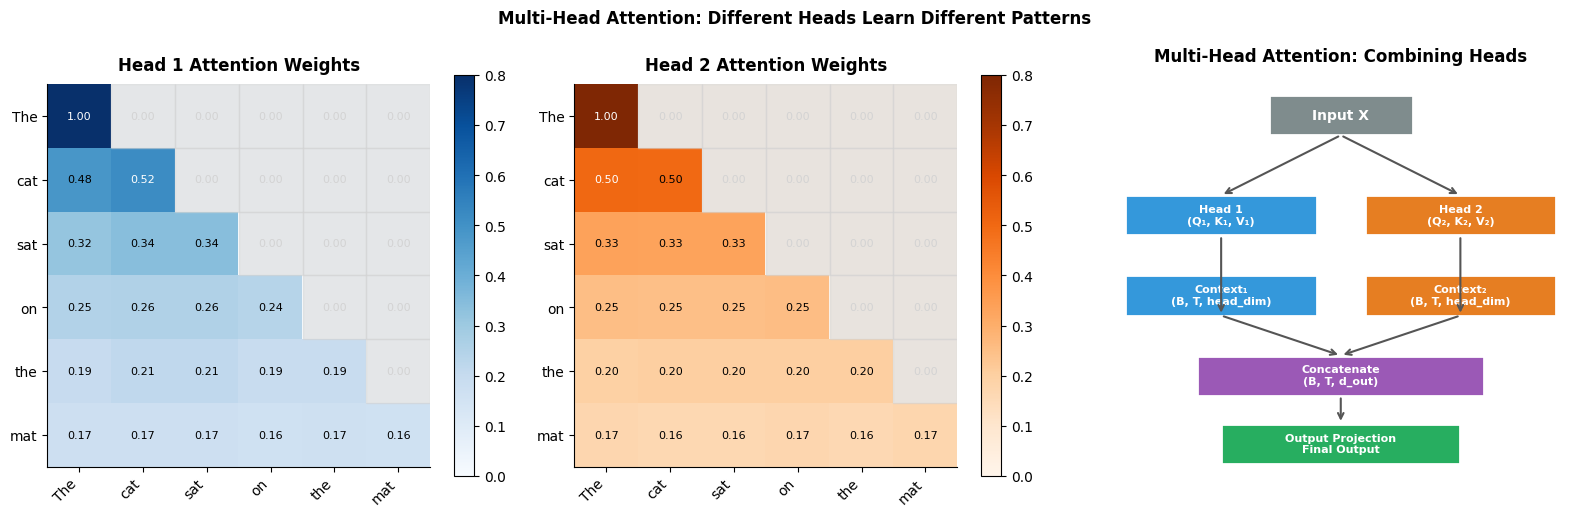

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch

# Example words
words = ["The", "cat", "sat", "on", "the", "mat"]
seq_len = len(words)

# Example attention weights if not already available
# Shape: (batch_size, num_heads, seq_len, seq_len)
if 'attn_weights' not in globals():
    attn_weights = torch.rand(1, 2, seq_len, seq_len)

    # Apply causal mask and normalize
    for h in range(2):
        w = torch.tril(attn_weights[0, h])
        w = w / w.sum(dim=-1, keepdim=True)
        attn_weights[0, h] = w

# ─── Visualize: Head 1 vs Head 2 Attention Patterns ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

head_colors = ['Blues', 'Oranges']

for h in range(2):

    w = attn_weights[0, h].detach().cpu().numpy()

    im = axes[h].imshow(w, cmap=head_colors[h], vmin=0, vmax=0.8)

    axes[h].set_xticks(range(seq_len))
    axes[h].set_xticklabels(words, rotation=45, ha='right')

    axes[h].set_yticks(range(seq_len))
    axes[h].set_yticklabels(words)

    axes[h].set_title(
        f'Head {h+1} Attention Weights',
        fontweight='bold',
        pad=10
    )

    plt.colorbar(im, ax=axes[h])

    for i in range(seq_len):
        for j in range(seq_len):

            axes[h].text(
                j,
                i,
                f'{w[i,j]:.2f}',
                ha='center',
                va='center',
                fontsize=8,
                color=(
                    'white' if w[i,j] > 0.5
                    else ('lightgray' if j > i else 'black')
                )
            )

        # Grey out future tokens
        for j in range(i + 1, seq_len):
            axes[h].add_patch(
                mpatches.Rectangle(
                    (j - 0.5, i - 0.5),
                    1,
                    1,
                    color='lightgray',
                    alpha=0.5
                )
            )

# ─── Multi-Head Architecture Diagram ─────────────────────────────────────────
ax3 = axes[2]
ax3.axis('off')

ax3.set_title(
    'Multi-Head Attention: Combining Heads',
    fontweight='bold',
    pad=10
)

ax3.set_xlim(0, 10)
ax3.set_ylim(0, 10)

def box(x, y, w, h, txt, color, fs=8):
    rect = plt.Rectangle(
        (x, y),
        w,
        h,
        color=color,
        ec='white',
        lw=2
    )
    ax3.add_patch(rect)

    ax3.text(
        x + w/2,
        y + h/2,
        txt,
        ha='center',
        va='center',
        fontsize=fs,
        fontweight='bold',
        color='white',
        wrap=True
    )

box(3.5, 8.5, 3, 1, 'Input X', '#7f8c8d', 10)

box(0.5, 6.0, 4, 1,
    'Head 1\n(Q₁, K₁, V₁)',
    '#3498db')

box(5.5, 6.0, 4, 1,
    'Head 2\n(Q₂, K₂, V₂)',
    '#e67e22')

box(0.5, 4.0, 4, 1,
    'Context₁\n(B, T, head_dim)',
    '#3498db')

box(5.5, 4.0, 4, 1,
    'Context₂\n(B, T, head_dim)',
    '#e67e22')

box(2.0, 2.0, 6, 1,
    'Concatenate\n(B, T, d_out)',
    '#9b59b6')

box(2.5, 0.3, 5, 1,
    'Output Projection\nFinal Output',
    '#27ae60')

# Arrows
for cx in [2.5, 7.5]:
    ax3.annotate(
        '',
        xy=(cx, 7.0),
        xytext=(5.0, 8.5),
        arrowprops=dict(
            arrowstyle='->',
            color='#555',
            lw=1.5
        )
    )

for cx in [2.5, 7.5]:
    ax3.annotate(
        '',
        xy=(cx, 4.0),
        xytext=(cx, 6.0),
        arrowprops=dict(
            arrowstyle='->',
            color='#555',
            lw=1.5
        )
    )

ax3.annotate(
    '',
    xy=(5.0, 3.0),
    xytext=(2.5, 4.0),
    arrowprops=dict(arrowstyle='->', color='#555', lw=1.5)
)

ax3.annotate(
    '',
    xy=(5.0, 3.0),
    xytext=(7.5, 4.0),
    arrowprops=dict(arrowstyle='->', color='#555', lw=1.5)
)

ax3.annotate(
    '',
    xy=(5.0, 1.3),
    xytext=(5.0, 2.0),
    arrowprops=dict(arrowstyle='->', color='#555', lw=1.5)
)

plt.suptitle(
    'Multi-Head Attention: Different Heads Learn Different Patterns',
    fontsize=12,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

---
## 📐 Section 7: Tensor Shape Guide — Following the Data Flow

One of the trickiest parts of understanding attention is keeping track of tensor shapes.  
Let's trace exactly how dimensions change at every step.

In [16]:
print("=" * 65)
print("  TENSOR SHAPE GUIDE: Multi-Head Attention Step-by-Step")
print("=" * 65)

B         = 2    # Batch size (number of sentences processed at once)
T         = 6    # Sequence length (number of tokens/words)
d_in      = 3    # Input embedding dimension
d_out     = 4    # Total output dimension
H         = 2    # Number of attention heads
head_dim  = d_out // H   # Per-head dimension

print(f"\n  Settings: Batch={B}, Tokens={T}, d_in={d_in}, d_out={d_out}, Heads={H}")
print()

steps = [
    ("Input X",            f"({B}, {T}, {d_in})",              "B sequences, T tokens, d_in dims each"),
    ("After W_Q/W_K/W_V",  f"({B}, {T}, {d_out})",             "Projected to d_out dimensions"),
    ("After .view()",      f"({B}, {T}, {H}, {head_dim})",     "Split d_out into H heads"),
    ("After .transpose()", f"({B}, {H}, {T}, {head_dim})",     "Heads dimension moved forward"),
    ("Q @ Kᵀ",             f"({B}, {H}, {T}, {T})",            "Attention score matrix per head"),
    ("After softmax",      f"({B}, {H}, {T}, {T})",            "Attention weights (rows sum to 1)"),
    ("× V",                f"({B}, {H}, {T}, {head_dim})",     "Context vectors per head"),
    ("After .transpose()", f"({B}, {T}, {H}, {head_dim})",     "Heads dimension moved back"),
    ("After .view()",      f"({B}, {T}, {d_out})",              "Heads merged (concatenated)"),
    ("After out_proj",     f"({B}, {T}, {d_out})",              "Final linear mix of heads"),
]

for step, shape, desc in steps:
    print(f"  {step:25s}  {shape:25s}  ← {desc}")

print()
print("  Key insight: The .view() + .transpose() operations are the")
print("  'weight split' trick — they implicitly create H parallel heads")
print("  without duplicating any data in memory!")

  TENSOR SHAPE GUIDE: Multi-Head Attention Step-by-Step

  Settings: Batch=2, Tokens=6, d_in=3, d_out=4, Heads=2

  Input X                    (2, 6, 3)                  ← B sequences, T tokens, d_in dims each
  After W_Q/W_K/W_V          (2, 6, 4)                  ← Projected to d_out dimensions
  After .view()              (2, 6, 2, 2)               ← Split d_out into H heads
  After .transpose()         (2, 2, 6, 2)               ← Heads dimension moved forward
  Q @ Kᵀ                     (2, 2, 6, 6)               ← Attention score matrix per head
  After softmax              (2, 2, 6, 6)               ← Attention weights (rows sum to 1)
  × V                        (2, 2, 6, 2)               ← Context vectors per head
  After .transpose()         (2, 6, 2, 2)               ← Heads dimension moved back
  After .view()              (2, 6, 4)                  ← Heads merged (concatenated)
  After out_proj             (2, 6, 4)                  ← Final linear mix of heads

  Key insi

---
## 🚀 Section 8: Real-World Scale — From 3D to GPT-4

Our examples used tiny dimensions for clarity. Let's see what real models use.

In [17]:
print("=" * 70)
print("  MULTI-HEAD ATTENTION PARAMETERS ACROSS REAL MODELS")
print("=" * 70)
print()

models = [
    ("Our Toy Example",     3,     4,   2,    6),
    ("GPT-2 Small",       768,   768,  12, 1024),
    ("GPT-2 Large",      1280,  1280,  20, 1024),
    ("GPT-3 (175B)",     12288, 12288, 96, 2048),
    ("GPT-4 (estimated)", 8192,  8192, 64, 8192),
]

print(f"  {'Model':22s} | {'d_in':>6} | {'d_out':>6} | {'Heads':>5} | {'Head Dim':>8} | {'Context':>7} |  Attn Params")
print(f"  {'-'*22}-+-{'-'*6}-+-{'-'*6}-+-{'-'*5}-+-{'-'*8}-+-{'-'*7}-+-{'-'*12}")

for name, d_in, d_out, H, ctx in models:
    head_dim = d_out // H
    # W_Q + W_K + W_V + out_proj (each d_in × d_out)
    params = 4 * d_in * d_out
    params_str = f"{params:,}" if params < 1_000_000 else f"{params/1e6:.1f}M"
    print(f"  {name:22s} | {d_in:>6,} | {d_out:>6,} | {H:>5} | {head_dim:>8} | {ctx:>7,} | {params_str:>12}")

print()
print("  Note: GPT-4's exact architecture is not officially published.")
print("  The '175B' in GPT-3 refers to TOTAL parameters across ALL layers (96 blocks).")
print()
print("  For GPT-2 Small: 12 heads × 64 head_dim = 768 total d_out")
print("  Each head independently learns what patterns to focus on!")

  MULTI-HEAD ATTENTION PARAMETERS ACROSS REAL MODELS

  Model                  |   d_in |  d_out | Heads | Head Dim | Context |  Attn Params
  -----------------------+--------+--------+-------+----------+---------+-------------
  Our Toy Example        |      3 |      4 |     2 |        2 |       6 |           48
  GPT-2 Small            |    768 |    768 |    12 |       64 |   1,024 |         2.4M
  GPT-2 Large            |  1,280 |  1,280 |    20 |       64 |   1,024 |         6.6M
  GPT-3 (175B)           | 12,288 | 12,288 |    96 |      128 |   2,048 |       604.0M
  GPT-4 (estimated)      |  8,192 |  8,192 |    64 |      128 |   8,192 |       268.4M

  Note: GPT-4's exact architecture is not officially published.
  The '175B' in GPT-3 refers to TOTAL parameters across ALL layers (96 blocks).

  For GPT-2 Small: 12 heads × 64 head_dim = 768 total d_out
  Each head independently learns what patterns to focus on!


---
## 📝 Section 9: Summary & Key Takeaways

### What We Built (From Scratch!)

```
Step 1: Word Embeddings       → Words as vectors in high-dimensional space
Step 2: Simple Self-Attention → Dot-product similarity between all word pairs
Step 3: Trainable Attention   → Q, K, V projections (the real mechanism)
Step 4: Causal Masking        → Block future tokens to prevent cheating
Step 5: Multi-Head Attention  → H parallel heads, each learning different patterns
```

### The Core Formula

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

| Symbol | What it is | Role |
|--------|-----------|------|
| **Q** | Query | "What am I looking for?" |
| **K** | Key | "What do I contain / offer?" |
| **V** | Value | "What information do I hold?" |
| **d_k** | Key dimension | Scaling factor (prevents exploding scores) |
| **softmax** | Normalization | Converts scores → probabilities |

### Why Self-Attention is Powerful

1. **Any-range dependencies** — Can connect word 1 to word 1000 in a single step (unlike RNNs which process sequentially)
2. **Parallelizable** — All attention scores computed simultaneously (great for GPUs)
3. **Interpretable** — Attention weights tell us what the model is "looking at"
4. **Multi-perspective** — Multiple heads capture different linguistic phenomena

### Where to Go Next

- 🧱 **Transformer Block** = Multi-Head Attention + Layer Norm + Feed-Forward + Skip Connections  
- 🤖 **GPT Architecture** = Stack of N Transformer Blocks  
- 🎓 **Fine-tuning** = Take a pretrained model and adapt it to specific tasks  
- 📖 **Papers**: "Attention is All You Need" (Vaswani et al., 2017) — the original paper!

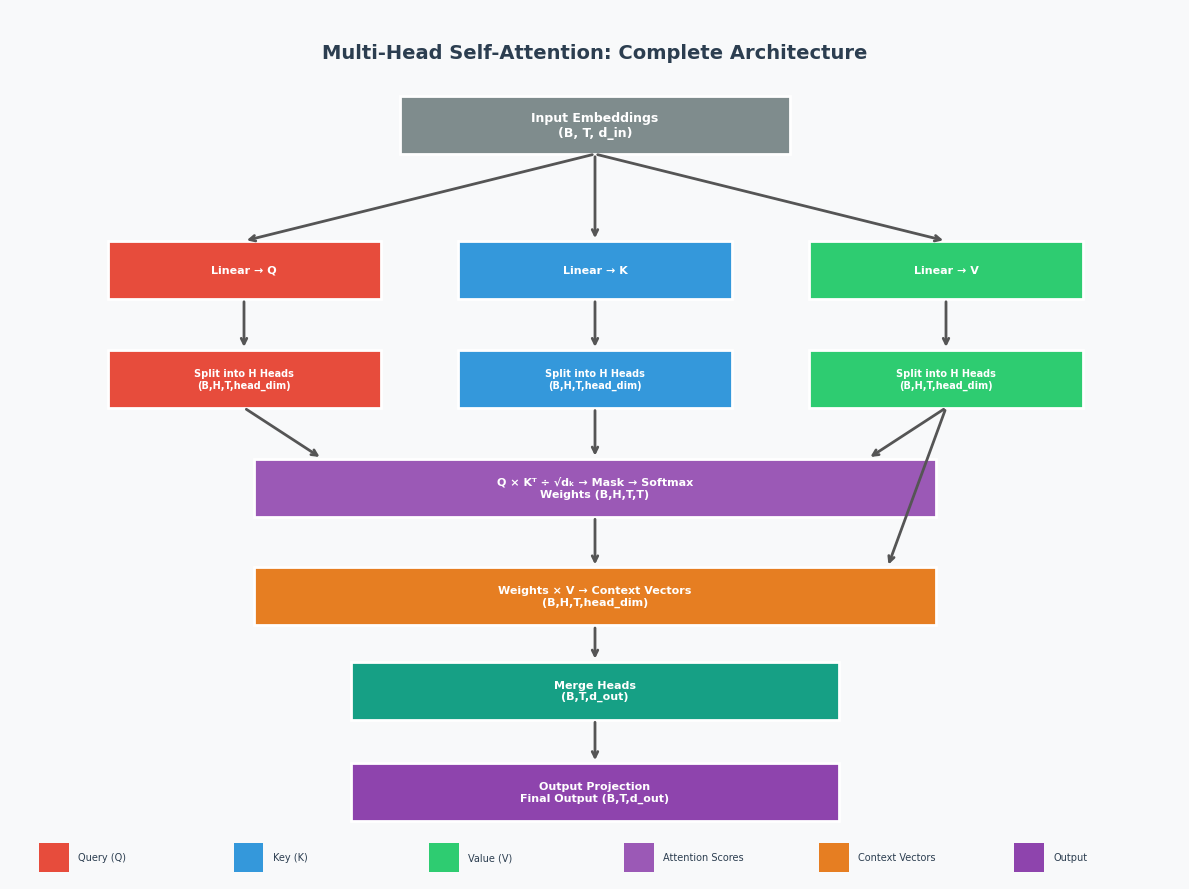

In [19]:
import matplotlib.pyplot as plt

# ─── Final Architecture Overview ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))

ax.set_xlim(0, 12)
ax.set_ylim(0, 12)
ax.axis('off')

ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')


# ─── Helper Functions ─────────────────────────────────────────────────────────
def b(ax, x, y, w, h, txt, fc, ec='white', fs=9, tc='white'):
    ax.add_patch(
        plt.Rectangle(
            (x, y),
            w,
            h,
            facecolor=fc,
            edgecolor=ec,
            lw=2,
            zorder=3
        )
    )

    ax.text(
        x + w/2,
        y + h/2,
        txt,
        ha='center',
        va='center',
        fontsize=fs,
        fontweight='bold',
        color=tc,
        zorder=4
    )


def arr(ax, x1, y1, x2, y2, label=''):
    ax.annotate(
        '',
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle='->',
            color='#555',
            lw=2
        )
    )

    if label:
        ax.text(
            (x1 + x2) / 2 + 0.2,
            (y1 + y2) / 2,
            label,
            fontsize=7,
            color='#777',
            ha='left',
            va='center'
        )


# ─── Title ────────────────────────────────────────────────────────────────────
ax.text(
    6,
    11.4,
    'Multi-Head Self-Attention: Complete Architecture',
    ha='center',
    va='center',
    fontsize=14,
    fontweight='bold',
    color='#2c3e50'
)

# ─── Input ────────────────────────────────────────────────────────────────────
b(
    ax,
    4,
    10.0,
    4,
    0.8,
    'Input Embeddings\n(B, T, d_in)',
    '#7f8c8d',
    fs=9
)

# ─── Q, K, V Projections ──────────────────────────────────────────────────────
b(ax, 1.0, 8.0, 2.8, 0.8, 'Linear → Q', '#e74c3c', fs=8)
b(ax, 4.6, 8.0, 2.8, 0.8, 'Linear → K', '#3498db', fs=8)
b(ax, 8.2, 8.0, 2.8, 0.8, 'Linear → V', '#2ecc71', fs=8)

for cx in [2.4, 6.0, 9.6]:
    arr(ax, 6.0, 10.0, cx, 8.8)

# ─── Split Into Heads ─────────────────────────────────────────────────────────
b(
    ax,
    1.0,
    6.5,
    2.8,
    0.8,
    'Split into H Heads\n(B,H,T,head_dim)',
    '#e74c3c',
    fs=7
)

b(
    ax,
    4.6,
    6.5,
    2.8,
    0.8,
    'Split into H Heads\n(B,H,T,head_dim)',
    '#3498db',
    fs=7
)

b(
    ax,
    8.2,
    6.5,
    2.8,
    0.8,
    'Split into H Heads\n(B,H,T,head_dim)',
    '#2ecc71',
    fs=7
)

for cx in [2.4, 6.0, 9.6]:
    arr(ax, cx, 8.0, cx, 7.3)

# ─── Attention Score Calculation ──────────────────────────────────────────────
b(
    ax,
    2.5,
    5.0,
    7.0,
    0.8,
    'Q × Kᵀ ÷ √dₖ → Mask → Softmax\nWeights (B,H,T,T)',
    '#9b59b6',
    fs=8
)

arr(ax, 2.4, 6.5, 3.2, 5.8)
arr(ax, 6.0, 6.5, 6.0, 5.8)
arr(ax, 9.6, 6.5, 8.8, 5.8)

# ─── Context Vector Computation ───────────────────────────────────────────────
b(
    ax,
    2.5,
    3.5,
    7.0,
    0.8,
    'Weights × V → Context Vectors\n(B,H,T,head_dim)',
    '#e67e22',
    fs=8
)

arr(ax, 6.0, 5.0, 6.0, 4.3)
arr(ax, 9.6, 6.5, 9.0, 4.3)

# ─── Merge Heads ──────────────────────────────────────────────────────────────
b(
    ax,
    3.5,
    2.2,
    5.0,
    0.8,
    'Merge Heads\n(B,T,d_out)',
    '#16a085',
    fs=8
)

arr(ax, 6.0, 3.5, 6.0, 3.0)

# ─── Output Projection ────────────────────────────────────────────────────────
b(
    ax,
    3.5,
    0.8,
    5.0,
    0.8,
    'Output Projection\nFinal Output (B,T,d_out)',
    '#8e44ad',
    fs=8
)

arr(ax, 6.0, 2.2, 6.0, 1.6)

# ─── Legend ───────────────────────────────────────────────────────────────────
legend_items = [
    ('#e74c3c', 'Query (Q)'),
    ('#3498db', 'Key (K)'),
    ('#2ecc71', 'Value (V)'),
    ('#9b59b6', 'Attention Scores'),
    ('#e67e22', 'Context Vectors'),
    ('#8e44ad', 'Output')
]

for i, (color, label) in enumerate(legend_items):

    ax.add_patch(
        plt.Rectangle(
            (0.3 + i * 2.0, 0.1),
            0.3,
            0.4,
            facecolor=color,
            zorder=3
        )
    )

    ax.text(
        0.7 + i * 2.0,
        0.3,
        label,
        va='center',
        fontsize=7,
        color='#2c3e50'
    )

plt.tight_layout()
plt.show()

---

#

we built **Multi-Head Self-Attention from scratch** — the core building block behind GPT, BERT, and virtually every state-of-the-art language model.

### Quick Recap

```python
# The complete attention formula in ~10 lines:
Q, K, V = W_q(x), W_k(x), W_v(x)          # Project to Q, K, V
Q = Q.view(B, T, H, h).transpose(1,2)       # Split into H heads
K = K.view(B, T, H, h).transpose(1,2)
V = V.view(B, T, H, h).transpose(1,2)
scores = Q @ K.transpose(-2,-1) / h**0.5    # Scaled dot-product
scores.masked_fill_(future_mask, -inf)       # Causal mask
weights = softmax(scores, dim=-1)            # Attention weights
out = (weights @ V).transpose(1,2).view(B, T, d_out)  # Merge heads
out = out_proj(out)                          # Final projection
```

### What's Next?
- Add **Layer Normalization** and **Feed-Forward Networks** → you have a **Transformer Block**
- Stack multiple Transformer Blocks → you have **GPT**!

---